<a href="https://colab.research.google.com/github/mrpellegrino/EMISSOR_NFCE_BLING/blob/main/Tarefa_2_Python_%2B_HuggingFace_%2B_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experimentando o Bert

Dayvson Pellegrino Rodriguês

In [16]:
from sentence_transformers import SentenceTransformer


# carregando modelo

#model = SentenceTransformer('all-MiniLM-L6-v2')
model = SentenceTransformer('BAAI/bge-m3')

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

In [17]:
#Frases

sentences = [
    "Eu gosto de futbol",
    "Eu adoro esporte",
    "Os carros aceleram rapidamente",
    "A ia dominara o mundo"

]

embeddings = model.encode(sentences)
print(embeddings)

[[-0.00441082 -0.01452423 -0.06588899 ... -0.01139638 -0.04787321
   0.02315585]
 [ 0.02204894 -0.03494006 -0.03951963 ...  0.00223864 -0.03314738
   0.03055988]
 [-0.02611566  0.02069897 -0.02951734 ...  0.01213405 -0.03176259
   0.03298014]
 [ 0.02696843  0.04177284 -0.03064555 ...  0.03573332 -0.02838785
   0.00618407]]


In [18]:
from sentence_transformers import util

# Calcula a similaridade de cosseno entre todos os pares
cosine_scores = util.cos_sim(embeddings, embeddings)

# Exibe os resultados para cada par
for i in range(len(sentences)):
    for j in range(i + 1, len(sentences)):
        print(f"Frase 1: {sentences[i]}")
        print(f"Frase 2: {sentences[j]}")
        print(f"Similaridade: {cosine_scores[i][j]:.4f}\n")

Frase 1: Eu gosto de futbol
Frase 2: Eu adoro esporte
Similaridade: 0.7798

Frase 1: Eu gosto de futbol
Frase 2: Os carros aceleram rapidamente
Similaridade: 0.5424

Frase 1: Eu gosto de futbol
Frase 2: A ia dominara o mundo
Similaridade: 0.4121

Frase 1: Eu adoro esporte
Frase 2: Os carros aceleram rapidamente
Similaridade: 0.5222

Frase 1: Eu adoro esporte
Frase 2: A ia dominara o mundo
Similaridade: 0.4468

Frase 1: Os carros aceleram rapidamente
Frase 2: A ia dominara o mundo
Similaridade: 0.4061



In [19]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------
# Catálogo de produtos
# -----------------------------
products = [
    "Tênis esportivo preto para corrida com amortecimento",
    "calçado adequado para corrida",
    "Nike AirJordan azul",
    "Sapato social masculino de couro",
    "Jaqueta jeans feminina oversized",
    "Bota marrom impermeável para trilha",
    "Vestido elegante vermelho para festa",
    "Moletom casual com capuz",
    "Sandália confortável para caminhada",
    "Sandália macia para caminhada",
    "Camisa social slim fit branca",
    "Tênis casual urbano estilo streetwear",
    "Calça legging para academia",
    "iPhone 17 Pro Max"
]

# --------------------------
# Embeddings do catálogo
# -----------------------------
product_embeddings = model.encode(products)

In [20]:
# -----------------------------
# Busca do usuário
# -----------------------------
query = "tênis confortável para correr"

query_embedding = model.encode([query])

# -----------------------------
# Similaridade semântica
# -----------------------------
similarities = cosine_similarity(
    query_embedding,
    product_embeddings
)[0]

# -----------------------------
# Ranking
# -----------------------------
ranking = np.argsort(similarities)[::-1]

print(f"\nBusca: {query}\n")

for idx in ranking:
    print(f"Score: {similarities[idx]:.4f}")
    print(f"Produto: {products[idx]}")
    print("-" * 60)


Busca: tênis confortável para correr

Score: 0.7496
Produto: Sandália confortável para caminhada
------------------------------------------------------------
Score: 0.7485
Produto: calçado adequado para corrida
------------------------------------------------------------
Score: 0.6780
Produto: Tênis esportivo preto para corrida com amortecimento
------------------------------------------------------------
Score: 0.6224
Produto: Tênis casual urbano estilo streetwear
------------------------------------------------------------
Score: 0.5950
Produto: Sandália macia para caminhada
------------------------------------------------------------
Score: 0.5852
Produto: Calça legging para academia
------------------------------------------------------------
Score: 0.5371
Produto: Sapato social masculino de couro
------------------------------------------------------------
Score: 0.5158
Produto: Bota marrom impermeável para trilha
------------------------------------------------------------
Score

In [21]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# -----------------------------
# Catálogo de produtos
# -----------------------------
products = [
    "Tênis esportivo preto para corrida com amortecimento",
    "calçado adequado para corrida",
    "Nike AirJordan azul",
    "Sapato social masculino de couro",
    "Jaqueta jeans feminina oversized",
    "Bota marrom impermeável para trilha",
    "Vestido elegante vermelho para festa",
    "Moletom casual com capuz",
    "Sandálias confortáveis para caminhada",
    "Sandália macia para caminhada",
    "Camisa social slim fit branca",
    "Tênis casual urbano estilo streetwear",
    "Calça legging para academia",
    "iPhone 17 Pro Max"
]

# --------------------------
# Embeddings do catálogo
# -----------------------------
product_embeddings = model.encode(products)

product_embeddings.shape

(14, 1024)

In [ ]:
from sklearn.cluster import KMeans

sentences = [
    "Comprei um tênis novo",
    "Sapato esportivo confortável",
    "Quero um calçado novo",
    "Bolsa caiu na bolsa de valores",
    "Ações da VALE caíram na bolsa hoje",
    "Ações subiram hoje",
    "Vou investir no S&P 500",
]

embeddings = model.encode(sentences)

kmeans = KMeans(n_clusters=2)
labels = kmeans.fit_predict(embeddings)

print(labels)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


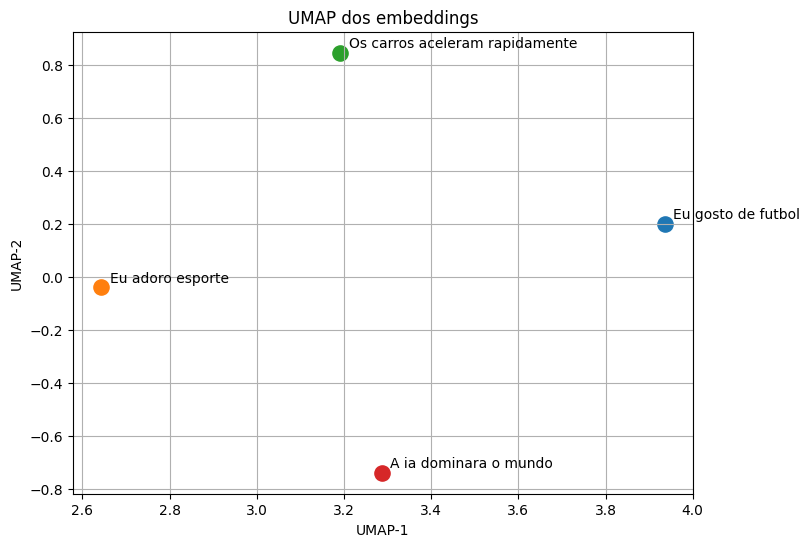

In [22]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
import umap.umap_ as umap
import matplotlib.pyplot as plt


# -----------------------------
# Redução de dimensionalidade
# -----------------------------
reducer = umap.UMAP(
    n_neighbors=3,
    min_dist=0.1,
    metric="cosine",
    random_state=42
)

embedding_2d = reducer.fit_transform(embeddings)

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8, 6))

for i, sentence in enumerate(sentences):
    x = embedding_2d[i, 0]
    y = embedding_2d[i, 1]

    plt.scatter(x, y, s=120)
    plt.text(x + 0.02, y + 0.02, sentence)

plt.title("UMAP dos embeddings")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.grid(True)